In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

import joblib

In [ ]:
import pandas as pd
import random

skills = [
    "Python", "Java", "SQL", "Machine Learning",
    "React", "AWS", "Docker", "Data Analysis"
]

education = [
    "B.Tech", "M.Tech", "B.Sc", "M.Sc", "MBA"
]

certifications = [
    "AWS Certified", "Google Data Analytics",
    "None", "Azure Fundamentals", "PMP"
]

job_roles = [
    "Data Scientist", "Software Engineer",
    "Data Analyst", "ML Engineer"
]

data = []

for i in range(1, 1001):
    exp = random.randint(0, 10)
    proj = random.randint(0, 20)
    salary = random.randint(30000, 120000)

    skill = ", ".join(random.sample(skills, 3))
    edu = random.choice(education)
    cert = random.choice(certifications)
    role = random.choice(job_roles)

    hire = 1 if exp >= 2 and proj >= 3 else 0

    data.append([
        i,
        skill,
        exp,
        edu,
        cert,
        role,
        hire,
        salary,
        proj
    ])

df = pd.DataFrame(data, columns=[
    "Resume_ID",
    "Skills",
    "Experience (Years)",
    "Education",
    "Certifications",
    "Job Role",
    "Recruiter Decision",
    "Salary Expectation ($)",
    "Projects Count"
])

df.to_csv("resume_dataset.csv", index=False)

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,Resume_ID,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count
0,1,"Java, Machine Learning, React",7,M.Sc,Azure Fundamentals,Data Analyst,1,60185,7
1,2,"Java, Docker, React",5,B.Tech,None,Data Analyst,0,117385,1
2,3,"Java, Data Analysis, React",10,B.Tech,Google Data Analytics,ML Engineer,1,84514,11
3,4,"AWS, Data Analysis, SQL",0,M.Tech,AWS Certified,Data Scientist,0,71392,12
4,5,"Machine Learning, AWS, SQL",10,B.Sc,PMP,Software Engineer,1,40940,3


In [ ]:
import pandas as pd

df = pd.read_csv('/content/resume_dataset.csv')
df.head()

,Resume_ID,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count
0,1,"Java, Machine Learning, React",7,M.Sc,Azure Fundamentals,Data Analyst,1,60185,7
1,2,"Java, Docker, React",5,B.Tech,NaN,Data Analyst,0,117385,1
2,3,"Java, Data Analysis, React",10,B.Tech,Google Data Analytics,ML Engineer,1,84514,11
3,4,"AWS, Data Analysis, SQL",0,M.Tech,AWS Certified,Data Scientist,0,71392,12
4,5,"Machine Learning, AWS, SQL",10,B.Sc,PMP,Software Engineer,1,40940,3


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Skills                  1000 non-null   object
 2   Experience (Years)      1000 non-null   int64 
 3   Education               1000 non-null   object
 4   Certifications          804 non-null    object
 5   Job Role                1000 non-null   object
 6   Recruiter Decision      1000 non-null   int64 
 7   Salary Expectation ($)  1000 non-null   int64 
 8   Projects Count          1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
Resume_ID                   0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            196
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count   

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Skills'] = le.fit_transform(df['Skills'])
df['Education'] = le.fit_transform(df['Education'])
df['Certifications'] = le.fit_transform(df['Certifications'])
df['Job_Role'] = le.fit_transform(df['Job_Role'])

KeyError: 'Job_Role'

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Skills'] = le.fit_transform(df['Skills'])
df['Education'] = le.fit_transform(df['Education'])
df['Certifications'] = le.fit_transform(df['Certifications'])
df['Job Role'] = le.fit_transform(df['Job Role'])

print("Encoding completed successfully!")

Encoding completed successfully!


In [ ]:
X = df.drop('Recruiter Decision', axis=1)
y = df['Recruiter Decision']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 8)
Target shape: (1000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train data:", X_train.shape)
print("Test data:", X_test.shape)

Train data: (800, 8)
Test data: (200, 8)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
import joblib

joblib.dump(model, 'hiring_prediction_model.pkl')

print("Model saved successfully!")

Model saved successfully!


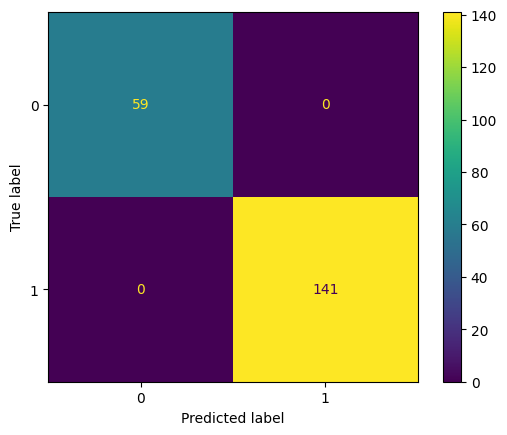

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00       141

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

